# 📊 EDIS 8100 · Week 2 · Exploring Learning Data

### Mapping the Learning Analytics Landscape and Theoretical Lenses

**Estimated time:** about 35 minutes of core work, in class.

*Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia*

---

## 🎯 Learning objectives

By the end of this notebook you will be able to:

1. **Aggregate** raw event data to the student level with `groupby`, and **join** two tables with `merge`.
2. **Read** a scatterplot of activity against achievement and say out loud what it does and does not license you to claim.
3. **Use the claim ladder** (feature, indicator, construct) to name the distance between a column in a CSV and a thing that theory says matters.
4. **Notice a temporal pattern** in when work gets submitted, and write one claim plus the evidence that would be needed to defend it.

---

## How this notebook works

New to code? Good. You are exactly who this was designed for.

- **Run the cells from top to bottom.** Click a cell and press **Shift + Enter**. Then do the next one.
- **Nothing here can break your computer.** This runs on a Google server, on invented data. The worst case is an error message, which is just the computer telling you where it got confused.
- **If something looks wrong, start over from the top.** In Colab: **Runtime > Restart and run all**. That fixes the large majority of problems, and it is what experienced people do too.
- **You never need to write code from scratch today.** The core path runs untouched. The cells marked ✏️ **Your turn** already contain working values, so the notebook runs whether or not you change them. Change them anyway when you get there.
- **Reading is the work.** The code is short. The interpretation prompts after each chart are the actual assignment.

**Section markers:** ⚙️ setup · 📊 analysis · ✏️ your turn · 💬 discuss · ✅ wrap up

## ⚙️ Setup: run the next cell first

The cell below builds this week's datasets right inside your Colab session: a roster, an LMS clickstream, and a gradebook for **EDUC 1010: Learning How to Learn**, a course at Blue Ridge University that does not exist.

The data are synthetic on purpose. Learning analytics runs on records about people who rarely got a say in being measured, and a class exercise is a poor reason to touch a real student's file. So we invented a world instead, and the ask in return is that you treat it as if it were real: ask who could be harmed by a claim before you make it.

In [1]:
# ⚙️ SETUP CELL: builds this week's synthetic datasets.
# This cell is long. It lives here so the notebook works in Colab with no downloads,
# no logins, and no network access. You are not expected to read it.
# Run it, collapse it (click the little triangle to the left), and move on.

"""EDIS 8100 data generation, the subset needed for week02.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
EVENT_TYPES = [
    "login", "page_view", "video_play", "video_pause",
    "forum_view", "assignment_view", "submit",
]
EVENT_BASE_P = np.array([0.12, 0.32, 0.16, 0.11, 0.13, 0.11, 0.05])
def make_clickstream(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """LMS event log for the eight course weeks.

    Two things vary across students and they are not the same thing. Volume is how
    many events a student generates, and it is heavy tailed. Regularity is how many
    separate days they show up at all. The week also has a rhythm: Monday and
    Tuesday spike ahead of the Tuesday night quiz deadline.

    Two subgroups break the "more clicks means more learning" story. Efficient
    students generate few events and score well (P1). First generation students
    working 15+ hours can only touch the course on a handful of days, so their
    regularity looks terrible even though their learning does not (P2).
    """
    rng = np.random.default_rng(SEED_CLICKSTREAM)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    regularity_z = _z(students["regularity"].to_numpy())
    efficient = students["efficient"].to_numpy()
    burst = students["burst_worker"].to_numpy()

    # Expected event count per student, lognormal so the tail is heavy.
    log_mu = (
        5.78
        + 0.40 * engagement
        + 0.05 * ability
        + 0.10 * regularity_z
        + np.log(np.where(efficient == 1, 0.30, 1.0))
        + np.log(np.where(burst == 1, 0.95, 1.0))
    )
    n_events = np.clip(
        np.round(np.exp(log_mu + rng.normal(0, 0.18, n))), 25, 4000
    ).astype(int)

    n_days = N_WEEKS * 7
    day_index = np.arange(n_days)
    weekday = (day_index + 0) % 7  # 0 = Monday, because 2026-09-07 is a Monday
    weekday_weight = np.array([1.45, 1.60, 1.10, 1.00, 0.75, 0.60, 1.05])
    weekday_rel = weekday_weight / weekday_weight.mean()
    week_of = day_index // 7
    week_weight = 1.0 - 0.022 * week_of  # attention fades a little across the term
    base_day_w = weekday_weight[weekday] * week_weight

    # Probability that a given student touches the course on a given day.
    p_active = _sigmoid(0.45 + 0.95 * regularity_z)
    # Working 15+ hours compresses the week into a couple of long evenings.
    p_active = np.where(burst == 1, p_active * 0.18, p_active)

    # Submit events crowd into the 48 hours before each Tuesday deadline.
    submit_day_w = np.where(np.isin(weekday, [0, 1]), 5.0, 0.70) * week_weight

    rows_student, rows_day, rows_type = [], [], []
    rows_hour = []

    for i in range(n):
        k = int(n_events[i])
        day_p = np.clip(p_active[i] * weekday_rel[weekday] * week_weight, 0.01, 0.97)
        active = rng.random(n_days) < day_p
        if active.sum() < 4:
            active[rng.choice(n_days, size=4, replace=False)] = True

        w = base_day_w * active * (0.55 + rng.gamma(3.0, 1.0 / 3.0, n_days))
        w = w / w.sum()
        sw = submit_day_w * active
        sw = sw / sw.sum()

        # Per-student taste for videos versus pages versus the forum.
        p_types = rng.dirichlet(EVENT_BASE_P * 55.0)
        types = rng.choice(len(EVENT_TYPES), size=k, p=p_types)

        days = rng.choice(n_days, size=k, p=w)
        is_submit = types == EVENT_TYPES.index("submit")
        if is_submit.any():
            days[is_submit] = rng.choice(n_days, size=int(is_submit.sum()), p=sw)

        # Time of day: three loose study sessions, later for procrastinators.
        centers = rng.choice(
            [9.6, 14.2, 20.8], size=k, p=[0.27, 0.33, 0.40]
        ) + 1.05 * procrast[i] * rng.random(k)
        hours = centers + rng.normal(0, 0.85, k)
        hours = np.clip(hours, 0.02, 23.97)

        rows_student.append(np.full(k, i))
        rows_day.append(days)
        rows_type.append(types)
        rows_hour.append(hours)

    student_idx = np.concatenate(rows_student)
    days = np.concatenate(rows_day)
    types = np.concatenate(rows_type)
    hours = np.concatenate(rows_hour)

    seconds = days * DAY_S + hours * 3600.0
    order = np.argsort(seconds, kind="stable")
    student_idx, days, types, seconds = (
        student_idx[order], days[order], types[order], seconds[order]
    )

    week = (days // 7 + 1).astype(int)
    type_names = np.array(EVENT_TYPES)[types]

    # Plausible resource ids per event type.
    resource = np.empty(seconds.size, dtype=object)
    page_no = rng.integers(1, 9, seconds.size)
    video_no = rng.integers(1, 5, seconds.size)
    thread_no = rng.integers(1, 61, seconds.size)
    for t, name in enumerate(EVENT_TYPES):
        mask = types == t
        if not mask.any():
            continue
        if name == "login":
            resource[mask] = "lms_home"
        elif name == "page_view":
            resource[mask] = [
                f"w{w}_page_{p:02d}" for w, p in zip(week[mask], page_no[mask])
            ]
        elif name in ("video_play", "video_pause"):
            resource[mask] = [
                f"w{w}_video_{v:02d}" for w, v in zip(week[mask], video_no[mask])
            ]
        elif name == "forum_view":
            resource[mask] = [f"thread_{t3:03d}" for t3 in thread_no[mask]]
        else:  # assignment_view and submit both point at the next quiz due
            deadline_days = np.array([QUIZ_DEADLINE_DAY[k] for k in range(1, N_WEEKS + 1)])
            next_quiz = np.clip(
                1 + np.searchsorted(deadline_days, days[mask], side="left"), 1, N_WEEKS
            )
            resource[mask] = [f"quiz_{k}" for k in next_quiz]

    df = pd.DataFrame(
        {
            "event_id": [f"E{i + 1:06d}" for i in range(seconds.size)],
            "student_id": students["student_id"].to_numpy()[student_idx],
            "timestamp": _iso(_ts(seconds)),
            "week": week,
            "event_type": type_names,
            "resource_id": resource,
        }
    )
    if write:
        df.to_csv(_outpath(outdir, "lms_clickstream.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_clickstream(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)

Data ready. Files created in ./data:
   gradebook.csv
   lms_clickstream.csv
   students.csv


## 📊 1. Meet the tables

Two files, two very different shapes, and the difference is the whole lesson of the first ten minutes.

- `lms_clickstream.csv` is a **log**: one row every time somebody clicked something. Nobody designed it to answer a research question. It is exhaust from a system doing its job.
- `gradebook.csv` is a **measurement**: one row per student per assessment, produced by an instrument somebody built on purpose.

Learning analytics almost always means putting the first kind of data next to the second kind and arguing about what the pairing means. Let us load them and look.

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Use matplotlib's default look, plus a faint grid, so every chart looks the same for everyone.
plt.style.use('default')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['figure.dpi'] = 100

# Load the three files we need this week.
clicks   = pd.read_csv('data/lms_clickstream.csv', parse_dates=['timestamp'])
grades   = pd.read_csv('data/gradebook.csv', parse_dates=['submitted_at', 'deadline'])
students = pd.read_csv('data/students.csv')

print('clickstream :', clicks.shape[0],   'rows x', clicks.shape[1],   'columns')
print('gradebook   :', grades.shape[0],   'rows x', grades.shape[1],   'columns')
print('roster      :', students.shape[0], 'rows x', students.shape[1], 'columns')
print()
print('One clickstream row is one event. Here are the first five:')
display(clicks.head())

clickstream : 41117 rows x 6 columns
gradebook   : 1080 rows x 5 columns
roster      : 120 rows x 9 columns

One clickstream row is one event. Here are the first five:


,event_id,student_id,timestamp,week,event_type,resource_id
0,E000001,S090,2026-09-07 06:29:36,1,video_pause,w1_video_03
1,E000002,S090,2026-09-07 06:50:04,1,video_pause,w1_video_03
2,E000003,S109,2026-09-07 07:00:17,1,forum_view,thread_054
3,E000004,S102,2026-09-07 07:03:53,1,submit,quiz_1
4,E000005,S102,2026-09-07 07:09:15,1,forum_view,thread_046


Now the gradebook. Notice the grain: one row is **one student in one assessment**, not one student. That distinction is going to matter in about four minutes.

In [3]:
display(grades.head())

print('Assessments in the gradebook:')
print(grades['assessment'].unique())
print()
print('Event types in the clickstream:')
print(clicks['event_type'].value_counts())

,student_id,assessment,score,submitted_at,deadline
0,S001,final_project,81.9,2026-11-09 02:56:39,2026-11-10 23:59:00
1,S001,quiz_1,84.3,2026-09-12 00:08:51,2026-09-15 23:59:00
2,S001,quiz_2,81.9,2026-09-15 01:29:23,2026-09-22 23:59:00
3,S001,quiz_3,76.6,2026-09-30 10:10:53,2026-09-29 23:59:00
4,S001,quiz_4,81.2,2026-10-05 04:17:44,2026-10-06 23:59:00


Assessments in the gradebook:
['final_project' 'quiz_1' 'quiz_2' 'quiz_3' 'quiz_4' 'quiz_5' 'quiz_6'
 'quiz_7' 'quiz_8']

Event types in the clickstream:
event_type
page_view          12899
video_play          6338
forum_view          5526
login               5084
assignment_view     4806
video_pause         4314
submit              2150
Name: count, dtype: int64


### 💬 Before you go further

41,117 rows of clicks exist for 120 students over eight weeks. Ask yourself, before any analysis:

- What did a student have to **do** for a `page_view` row to appear? What could a student do that would leave **no row at all**?
- Baker and Inventado (2014) point out that educational data mining and learning analytics grew up around exactly this kind of trace. Which questions does a log like this make easy to ask, and which questions does it quietly make impossible?

## 📊 2. From 41,117 events to 120 students: `groupby`

Right now the clickstream is at the wrong grain for almost any question we care about. We think in students; the file thinks in clicks. `groupby` is the tool that moves between grains.

`clicks.groupby('student_id').size()` says: *split the table into one pile per student, then count the rows in each pile.* One number per student comes back.

In [4]:
# Split by student, count the rows in each pile, name the result.
activity = (
    clicks.groupby('student_id')
          .size()
          .rename('total_events')
          .reset_index()
)

print('activity now has one row per student:', activity.shape)
display(activity.head())

print('Distribution of total events per student:')
print(activity['total_events'].describe().round(1))

activity now has one row per student: (120, 2)


,student_id,total_events
0,S001,338
1,S002,341
2,S003,218
3,S004,591
4,S005,269


Distribution of total events per student:
count     120.0
mean      342.6
std       202.0
min        25.0
25%       209.8
50%       307.5
75%       433.5
max      1144.0
Name: total_events, dtype: float64


Look at those summary numbers before you look at any picture. The median student generated a few hundred events; the busiest generated over a thousand. That gap is not a data error, it is the normal shape of behavioral trace data: **heavy tailed**. A histogram will make it obvious.

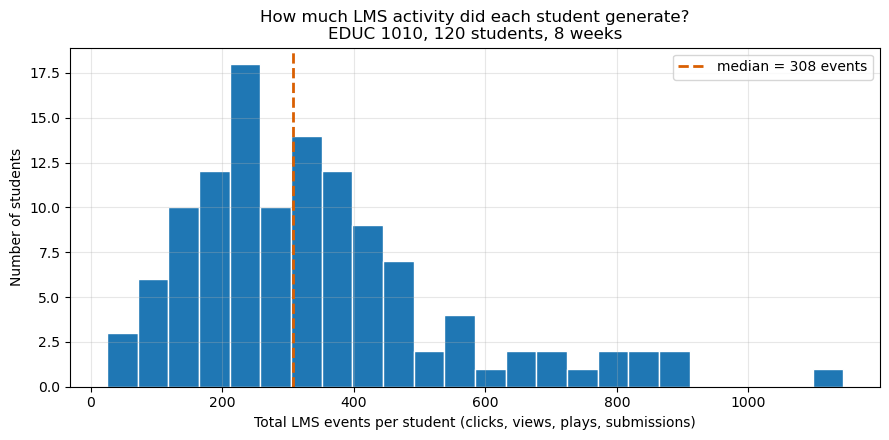

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(activity['total_events'], bins=24, color='#1f77b4', edgecolor='white')
ax.axvline(activity['total_events'].median(), color='#d95f02', linestyle='--', linewidth=2,
           label=f"median = {activity['total_events'].median():.0f} events")
ax.set_title('How much LMS activity did each student generate?\nEDUC 1010, 120 students, 8 weeks')
ax.set_xlabel('Total LMS events per student (clicks, views, plays, submissions)')
ax.set_ylabel('Number of students')
ax.legend()
plt.tight_layout()
plt.show()

### 💬 Interpret this chart

1. The tail on the right is real behavior, not noise. Name **two different students** who could have produced a count near the far right, one whose count you would read as good news and one whose count you would read as a warning sign.
2. The student at the far **left** generated 25 events all term. Write down three explanations that are consistent with that number. Only one of them is "disengaged."
3. If a dashboard showed a teacher this histogram on week 3, what would you predict the teacher does next? Is that action supported by anything on this chart?

### 📊 2b. Groups can have two keys

Educational meaning usually lives in the breakdown, not the total. The same `groupby` takes a list: split by student **and** by event type, then reshape so each event type becomes a column.

In [6]:
by_type = (
    clicks.groupby(['student_id', 'event_type'])
          .size()
          .unstack(fill_value=0)          # event types become columns
)

print('One row per student, one column per event type:')
display(by_type.head())

print('Class totals by event type:')
print(by_type.sum().sort_values(ascending=False))

One row per student, one column per event type:


event_type,assignment_view,forum_view,login,page_view,submit,video_pause,video_play
student_id,,,,,,,
S001,25,65,51,95,11,58,33
S002,34,72,39,104,29,27,36
S003,14,40,36,76,4,12,36
S004,71,26,52,192,40,66,144
S005,23,68,31,56,3,44,44


Class totals by event type:
event_type
page_view          12899
video_play          6338
forum_view          5526
login               5084
assignment_view     4806
video_pause         4314
submit              2150
dtype: int64


## 💬 3. The claim ladder: feature, indicator, construct

Stop here. This is the idea the rest of the semester leans on, and we are naming it in Week 2 so we can point back at it in Week 6 and Week 10.

`total_events` is a number. The moment you say a sentence about it, you have climbed a ladder, and most arguments in learning analytics are really arguments about which rung somebody is standing on.

| Rung | What it is | Today's example | How much argument it needs |
|---|---|---|---|
| **Feature** | Something the system recorded that you can count without anyone objecting. | `total_events = 412` for student S014. | Almost none. It is arithmetic. |
| **Indicator** | A feature you have **argued** stands in for something educational. | "Total events is an indicator of how engaged a student is with the course." | A lot. This is where the work is. |
| **Construct** | The thing you actually care about. Theory defines it. No column contains it. | Engagement. Self-regulated learning. Understanding. | It has a literature, and the literature disagrees. |

Nathan and Sawyer (2014) are useful here precisely because they refuse to let learning be defined by whatever is easy to capture. Their learning sciences constructs (deep conceptual understanding, knowledge built in context, learning made visible through activity) do not sit in a CSV column, and no amount of clicks adds up to one.

Baker and Inventado (2014) describe two research traditions that handle this differently: educational data mining tends to work bottom up from the features toward automated discovery, while learning analytics tends to keep a human holding the construct and asking whether the indicator deserves the name it was given. Neither is the villain. But you have to know which move you are making.

**House rule for the rest of the course:** when you make a claim, say which rung it is standing on. "S014 generated 412 events" is a feature claim and it is free. "S014 is engaged" is a construct claim and you owe evidence.

### ✏️ Write one line now

In the cell below (it is a text cell, just type), finish these three sentences:

- The feature I have is ...
- I am proposing to treat it as an indicator of ...
- The construct I actually care about is ..., and one thing this feature will definitely miss about it is ...

*(Your answer here. Double click this cell to type in it.)*

- The feature I have is
- I am proposing to treat it as an indicator of
- The construct I actually care about is

## 📊 4. The other table, then the join

To put activity next to achievement we need achievement at the same grain: one number per student.

Two decisions are hiding in the next three lines of code, and both are choices you should be able to defend:

1. We keep the **eight quizzes** and drop the final project, because the final project is a different kind of task on a different timeline. That is a judgment call. Someone could reasonably disagree.
2. We take the **mean** of a student's quiz scores. A mean hides growth. A student who went 55, 60, 68, 74, 80, 85, 88, 91 and a student who went flat at 75 can land in the same place. We are choosing to lose that information today, and Week 7 will come back for it.

In [7]:
# Keep quizzes only (quiz_1 ... quiz_8), drop the final project.
quizzes = grades[grades['assessment'].str.startswith('quiz')].copy()

achievement = (
    quizzes.groupby('student_id')['score']
           .mean()
           .rename('mean_quiz_score')
           .reset_index()
)

print('One row per student:', achievement.shape)
display(achievement.head())
print('Quiz scores across the class: mean %.1f, sd %.1f'
      % (quizzes['score'].mean(), quizzes['score'].std()))

One row per student: (120, 2)


,student_id,mean_quiz_score
0,S001,81.4125
1,S002,69.8750
2,S003,73.3250
3,S004,74.1500
4,S005,70.1875


Quiz scores across the class: mean 75.7, sd 13.0


### 📊 4b. `merge`: gluing two tables on a shared key

`merge` lines up two tables by a column they share. Here that column is `student_id`, the join key for every file in this course.

`how='inner'` keeps only students present in **both** tables. That is safe here (everyone has both), but in real work an inner join is where students quietly disappear from your analysis, so we print the count before and after every time.

In [8]:
panel = activity.merge(achievement, on='student_id', how='inner')

print('activity rows    :', len(activity))
print('achievement rows :', len(achievement))
print('after merge      :', len(panel), '  <- nobody was dropped')
display(panel.head())

activity rows    : 120
achievement rows : 120
after merge      : 120   <- nobody was dropped


,student_id,total_events,mean_quiz_score
0,S001,338,81.4125
1,S002,341,69.8750
2,S003,218,73.3250
3,S004,591,74.1500
4,S005,269,70.1875


## 📊 5. Does activity buy achievement?

This is the plot that launched a thousand dashboards: effort on the x axis, outcome on the y axis. Before you run it, **write down your prediction**. Most people expect a clear upward cloud.

We will add the least squares line and print the correlation, `r`. Two things to know about `r`:

- It runs from -1 to 1 and only describes a **straight line** relationship.
- `r` squared is the share of the variation in scores that moves with activity. That second number is usually the honest one to report.

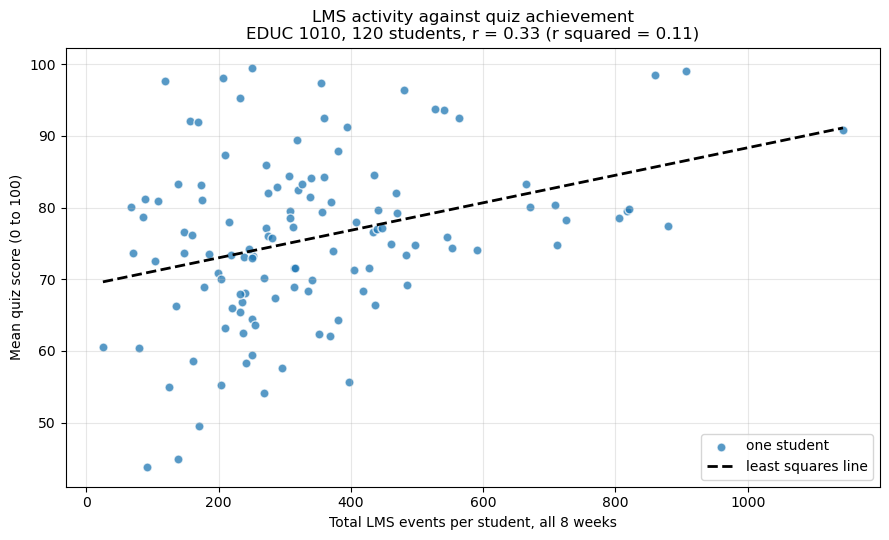

Correlation r = 0.335
r squared     = 0.112   ->  activity moves with about 11% of the variation in scores.


In [9]:
r = panel['total_events'].corr(panel['mean_quiz_score'])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(panel['total_events'], panel['mean_quiz_score'],
           s=42, color='#1f77b4', alpha=0.75, edgecolor='white', label='one student')

# Least squares line, drawn across the observed range of activity.
slope, intercept = np.polyfit(panel['total_events'], panel['mean_quiz_score'], 1)
xline = np.linspace(panel['total_events'].min(), panel['total_events'].max(), 100)
ax.plot(xline, slope * xline + intercept, color='#000000', linewidth=2,
        linestyle='--', label='least squares line')

ax.set_title('LMS activity against quiz achievement\nEDUC 1010, 120 students, r = %.2f (r squared = %.2f)'
             % (r, r ** 2))
ax.set_xlabel('Total LMS events per student, all 8 weeks')
ax.set_ylabel('Mean quiz score (0 to 100)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Correlation r = %.3f' % r)
print('r squared     = %.3f   ->  activity moves with about %.0f%% of the variation in scores.'
      % (r ** 2, 100 * r ** 2))

### 💬 Interpret this chart (take a full two minutes)

1. The line does slope up, and `r` is not zero. Say precisely what that licenses you to claim. Now say what it does **not** license.
2. About 89 percent of the variation in quiz scores is doing something other than tracking click volume. Name three plausible somethings.
3. Put your finger on the **lower left** of the plot, low activity. Are all of those students at the bottom of the score axis? Look carefully.
4. A vendor demo shows a college this exact chart and proposes an alert for students below the class median in activity. Using the claim ladder from Section 3, name the rung that pitch is standing on and the rung it is pretending to stand on.

### 📊 5b. Look at the students the line gets wrong

A regression line is an average, and averages are the story of nobody in particular. Two views make the misses visible.

First, a summary table: split the class into three equal groups by activity (`qcut` does this) and look at the spread of scores inside each group, not just the average.

In [10]:
panel['activity_tercile'] = pd.qcut(panel['total_events'], 3,
                                    labels=['low third', 'middle third', 'high third'])

tercile_table = (
    panel.groupby('activity_tercile', observed=True)
         .agg(students=('student_id', 'count'),
              median_events=('total_events', 'median'),
              mean_score=('mean_quiz_score', 'mean'),
              sd_of_score=('mean_quiz_score', 'std'),
              lowest_score=('mean_quiz_score', 'min'),
              highest_score=('mean_quiz_score', 'max'))
         .round(1)
)
display(tercile_table)

high_median = panel.loc[panel['activity_tercile'] == 'high third', 'mean_quiz_score'].median()
low_group   = panel[panel['activity_tercile'] == 'low third']
share_above = (low_group['mean_quiz_score'] > high_median).mean()

print('Median score of the HIGH activity third: %.1f' % high_median)
print('Share of LOW activity students who beat that median: %.0f%% (%d of %d students)'
      % (100 * share_above, (low_group['mean_quiz_score'] > high_median).sum(), len(low_group)))

,students,median_events,mean_score,sd_of_score,lowest_score,highest_score
activity_tercile,,,,,,
low third,40,169.5,72.4,13.4,43.8,98.1
middle third,40,307.5,75.3,10.7,54.2,99.5
high third,40,484.5,79.5,9.5,55.7,99.0


Median score of the HIGH activity third: 78.1
Share of LOW activity students who beat that median: 32% (13 of 40 students)


Read the table before the next chart. The group means climb from the low third to the high third, so the trend is real. But look at the `sd_of_score` and at `lowest_score` versus `highest_score` **within** each row: the range inside any one activity group is far wider than the distance between the groups. That is what an `r` of 0.33 looks like when you stop letting a single line speak for 120 people.

Now the second view. Let us find the students in the **low activity, high score** corner and put them on the map: bottom third of activity, top quarter of scores.

Activity cutoff (33rd percentile): 239 events
Score cutoff (75th percentile)   : 82.2 points
Students in the low activity, high score corner: 8


,student_id,total_events,mean_quiz_score
0,S048,206,98.0625
1,S076,119,97.6375
2,S009,232,95.3500
3,S006,157,92.1375
4,S099,169,91.9625
5,S025,209,87.3750
6,S016,138,83.3250
7,S109,173,83.1875


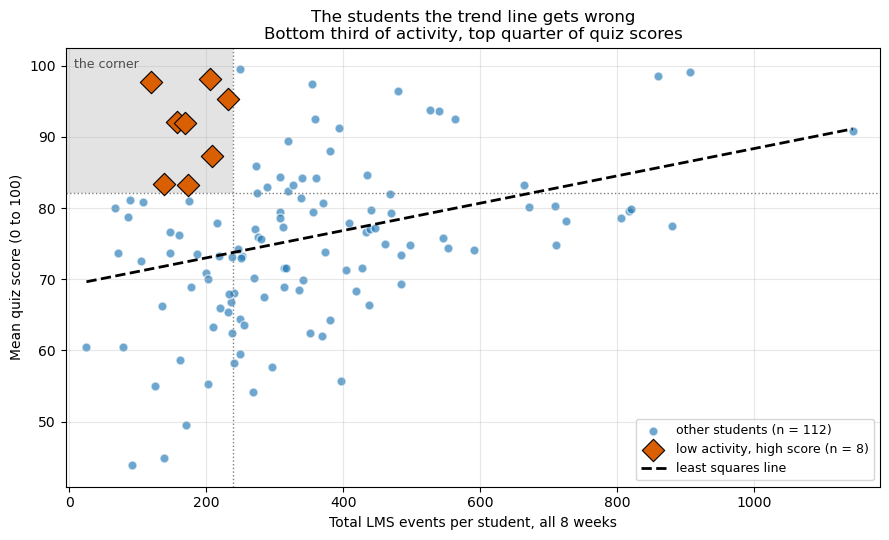

In [11]:
activity_cut = panel['total_events'].quantile(1 / 3)      # bottom third of activity
score_cut    = panel['mean_quiz_score'].quantile(0.75)    # top quarter of scores

corner = panel[(panel['total_events'] <= activity_cut) &
               (panel['mean_quiz_score'] >= score_cut)]

print('Activity cutoff (33rd percentile): %.0f events' % activity_cut)
print('Score cutoff (75th percentile)   : %.1f points' % score_cut)
print('Students in the low activity, high score corner: %d' % len(corner))
display(corner[['student_id', 'total_events', 'mean_quiz_score']]
        .sort_values('mean_quiz_score', ascending=False)
        .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 5.5))
x_lo, x_hi = panel['total_events'].min() - 30, panel['total_events'].max() + 40
y_lo, y_hi = panel['mean_quiz_score'].min() - 3, panel['mean_quiz_score'].max() + 3
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)

# Shade only the corner itself: low activity AND high score at the same time.
ax.add_patch(plt.Rectangle((x_lo, score_cut), activity_cut - x_lo, y_hi - score_cut,
                           facecolor='#bbbbbb', alpha=0.40, zorder=0))
ax.axhline(score_cut, color='#7f7f7f', linewidth=1, linestyle=':')
ax.axvline(activity_cut, color='#7f7f7f', linewidth=1, linestyle=':')
ax.text(x_lo + 12, y_hi - 1.5, 'the corner', fontsize=9, color='#4d4d4d', va='top')

others = panel.drop(corner.index)
ax.scatter(others['total_events'], others['mean_quiz_score'],
           s=42, color='#1f77b4', alpha=0.65, edgecolor='white',
           label='other students (n = %d)' % len(others))
ax.scatter(corner['total_events'], corner['mean_quiz_score'],
           s=130, color='#d95f02', marker='D', edgecolor='black', linewidth=0.8, zorder=3,
           label='low activity, high score (n = %d)' % len(corner))

ax.plot(xline, slope * xline + intercept, color='#000000', linewidth=2, linestyle='--',
        label='least squares line')

ax.set_title('The students the trend line gets wrong\nBottom third of activity, top quarter of quiz scores')
ax.set_xlabel('Total LMS events per student, all 8 weeks')
ax.set_ylabel('Mean quiz score (0 to 100)')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 💬 Interpret this chart

Eight students sit in the shaded corner, several of them near the top of the class, on roughly a third of the clicks of their peers.

1. Write **three** different stories that would produce a point in that corner. At least one should be flattering to the student, at least one should be worrying, and at least one should be about the **system** rather than the student.
2. A retention model that treats low activity as risk would flag every one of those eight. What is the cost of that error, and who pays it? (Hold that thought. Week 3 builds exactly that model and audits it.)
3. Reverse the frame. The busiest students, out on the right, average only a few points higher than the middle third. If effort is not converting to score, is that a student problem or a course design problem? What data would tell you the difference?
4. Baker and Inventado (2014) separate discovering structure in data from acting on it. Which of the two are you doing when you circle these eight students? Which one would you need permission for?

## ✏️ Your turn 1: build a different feature

`total_events` counts everything: logins, page views, video plays and pauses, forum views, assignment views, submissions. That is a decision, and decisions can be changed.

Change the list below to count only the event types you think belong in an "engagement" indicator, then re-run the cell. It already works as written, so run it once first to see the baseline.

Try, for example: only `video_play`, or drop `login` and `page_view`, or keep only `forum_view`.

In [12]:
# ✏️ EDIT THIS LIST. It runs as written; the default counts everything.
EVENT_TYPES = ['login', 'page_view', 'video_play', 'video_pause',
               'forum_view', 'assignment_view', 'submit']

# --- nothing below needs editing ---
if len(EVENT_TYPES) == 0:                       # a small guard so an empty list cannot break the cell
    print('EVENT_TYPES is empty, using all event types instead.')
    EVENT_TYPES = list(clicks['event_type'].unique())

subset = clicks[clicks['event_type'].isin(EVENT_TYPES)]
custom = (subset.groupby('student_id').size()
                .rename('custom_events').reset_index())

# Students with zero of the chosen event types would vanish from a groupby, so add them back at 0.
custom = achievement[['student_id']].merge(custom, on='student_id', how='left').fillna({'custom_events': 0})
custom = custom.merge(achievement, on='student_id')

r_custom = custom['custom_events'].corr(custom['mean_quiz_score'])
print('Counting event types:', EVENT_TYPES)
print('Events kept : %d of %d' % (len(subset), len(clicks)))
print('r with mean quiz score : %.3f   (baseline with everything: 0.335)' % r_custom)
print('Students with zero of these events: %d' % (custom['custom_events'] == 0).sum())

Counting event types: ['login', 'page_view', 'video_play', 'video_pause', 'forum_view', 'assignment_view', 'submit']
Events kept : 41117 of 41117
r with mean quiz score : 0.335   (baseline with everything: 0.335)
Students with zero of these events: 0


**Notice what just happened.** You changed a definition, not a fact about any student, and the number that a dashboard would report about them moved. Write one sentence naming which of your candidate features you would be willing to defend in front of the student it describes.

## 📊 6. When does the work happen?

So far we have squashed time flat. Every count in this notebook has treated a click in week 1 and a click in week 8 as the same thing. Time is usually where the educational story actually lives.

Eight quizzes, each due at 23:59 on a Tuesday. Let us count events per calendar day and mark the deadlines.

Quiz deadlines: ['Sep 15 (Tue)', 'Sep 22 (Tue)', 'Sep 29 (Tue)', 'Oct 06 (Tue)', 'Oct 13 (Tue)', 'Oct 20 (Tue)', 'Oct 27 (Tue)', 'Nov 03 (Tue)']
Clickstream covers Sep 07 to Nov 01


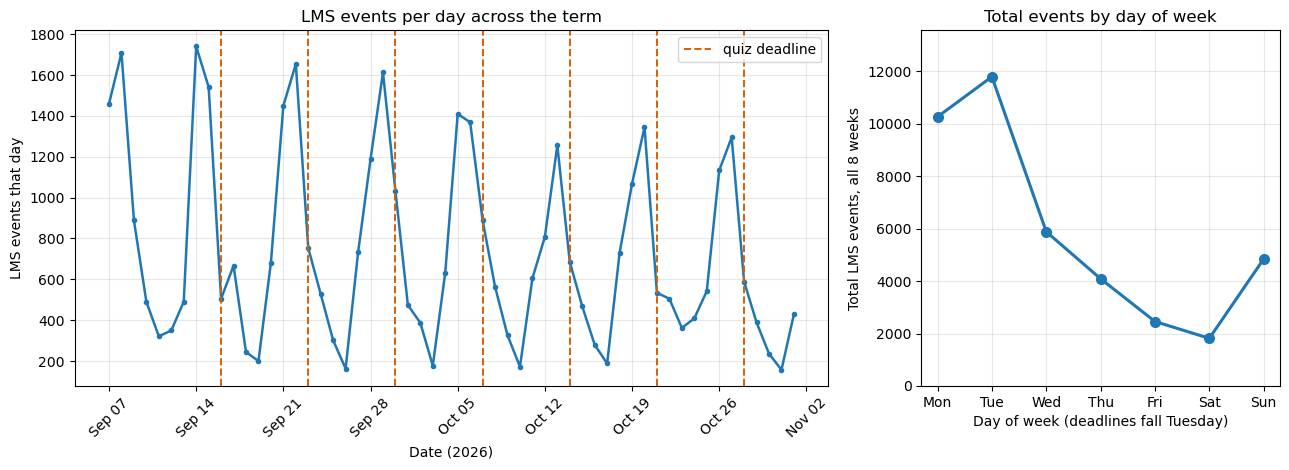


Total events by day of week:
dow
Mon    10257
Tue    11783
Wed     5878
Thu     4085
Fri     2457
Sat     1816
Sun     4841


In [13]:
# Count LMS events per calendar day.
daily = (clicks.assign(date=clicks['timestamp'].dt.date)
               .groupby('date').size().rename('events').reset_index())
daily['date'] = pd.to_datetime(daily['date'])

# The quiz deadlines, straight out of the gradebook.
deadlines = pd.to_datetime(sorted(quizzes['deadline'].unique()))
print('Quiz deadlines:', [d.strftime('%b %d (%a)') for d in deadlines])
print('Clickstream covers %s to %s'
      % (clicks['timestamp'].min().strftime('%b %d'), clicks['timestamp'].max().strftime('%b %d')))

# Average events per day of the week, Monday first.
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
by_dow = (clicks.assign(dow=clicks['timestamp'].dt.day_name().str[:3])
                .groupby('dow').size().reindex(dow_order))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8),
                               gridspec_kw={'width_ratios': [2.1, 1]})

ax1.plot(daily['date'], daily['events'], color='#1f77b4', linewidth=1.8, marker='o', markersize=3)
for i, d in enumerate(deadlines):
    if d <= clicks['timestamp'].max():
        ax1.axvline(d, color='#d95f02', linestyle='--', linewidth=1.4,
                    label='quiz deadline' if i == 0 else None)
ax1.set_title('LMS events per day across the term')
ax1.set_xlabel('Date (2026)')
ax1.set_ylabel('LMS events that day')
ax1.legend(loc='upper right')
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.tick_params(axis='x', rotation=45)

ax2.plot(dow_order, by_dow.values, color='#1f77b4', linewidth=2.2, marker='o', markersize=7)
ax2.set_title('Total events by day of week')
ax2.set_xlabel('Day of week (deadlines fall Tuesday)')
ax2.set_ylabel('Total LMS events, all 8 weeks')
ax2.set_ylim(0, by_dow.max() * 1.15)

plt.tight_layout()
plt.show()

print()
print('Total events by day of week:')
print(by_dow.to_string())

### 💬 Interpret this chart

1. The left panel has a shape you could set a clock by. Describe the weekly cycle in one sentence, then name the thing in the course design that is producing it. (Hint: the orange lines.)
2. The right panel says Tuesday and Monday together carry more events than Wednesday through Sunday combined. Is that a finding about students, or a finding about the course? What would this panel look like in a course with no fixed deadlines?
3. Look at the last deadline in the printed list against the last date in the clickstream. One deadline has no click data at all around it. What happens to any weekly analysis that does not notice that boundary?
4. Reich (2022) writes about what happens when learning is studied at scale through the traces platforms happen to keep. What is this rhythm mostly a trace of: the students, or the calendar the platform imposes on them?

## 📊 7. A closer look at the deadline itself

The rhythm chart says work piles up right before Tuesday at 23:59. The gradebook lets us ask a sharper question: does it matter **how close to the deadline** a submission lands?

For each quiz submission, compute the **lead time**: hours between the submission and its deadline. A big positive number means early. A number near zero means the last moments. A negative number means late.

This is a Week 8 topic and we are only opening the door on it today.

,submissions,share_of_all,mean_score,sd_of_score
timing,,,,
after the deadline,33,0.034,73.3,9.3
last 6 hours,175,0.182,68.2,12.0
6 to 24 hours,270,0.281,72.4,12.3
1 to 3 days,257,0.268,78.1,11.6
more than 3 days,225,0.234,83.3,11.8


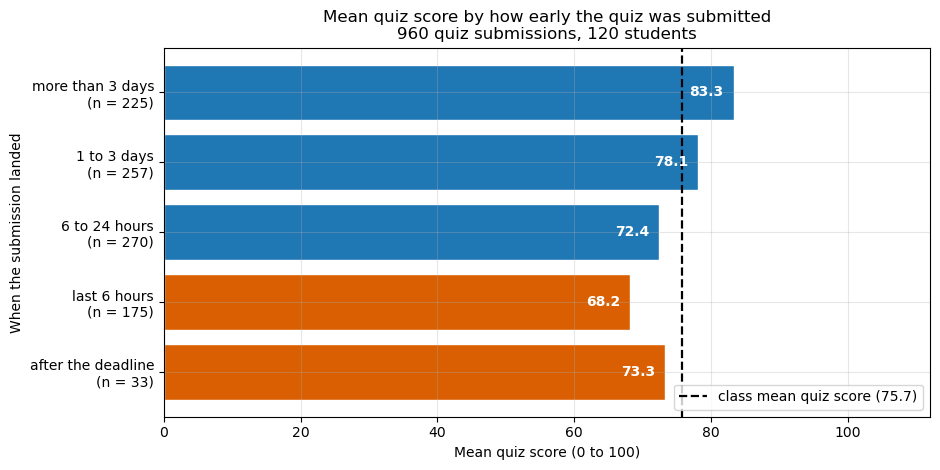

In [14]:
quizzes['lead_hours'] = (quizzes['deadline'] - quizzes['submitted_at']).dt.total_seconds() / 3600

bins   = [-np.inf, 0, 6, 24, 72, np.inf]
labels = ['after the deadline', 'last 6 hours', '6 to 24 hours', '1 to 3 days', 'more than 3 days']
quizzes['timing'] = pd.cut(quizzes['lead_hours'], bins=bins, labels=labels)

timing_table = (
    quizzes.groupby('timing', observed=True)
           .agg(submissions=('score', 'size'),
                share_of_all=('score', lambda s: len(s) / len(quizzes)),
                mean_score=('score', 'mean'),
                sd_of_score=('score', 'std'))
           .round({'share_of_all': 3, 'mean_score': 1, 'sd_of_score': 1})
)
display(timing_table)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
# barh draws the first item at the bottom, so latest submissions end up at the bottom.
order  = [l for l in labels if l in timing_table.index]
means  = timing_table.loc[order, 'mean_score']
counts = timing_table.loc[order, 'submissions']
ticks  = ['%s\n(n = %d)' % (l, n) for l, n in zip(order, counts)]
colors = ['#d95f02' if l in ('last 6 hours', 'after the deadline') else '#1f77b4' for l in order]
bars   = ax.barh(ticks, means.values, color=colors, edgecolor='white')
ax.axvline(quizzes['score'].mean(), color='#000000', linestyle='--', linewidth=1.6,
           label='class mean quiz score (%.1f)' % quizzes['score'].mean())
for bar, value in zip(bars, means.values):                     # value label inside the bar
    ax.text(value - 1.5, bar.get_y() + bar.get_height() / 2, '%.1f' % value,
            va='center', ha='right', fontsize=10, color='white', fontweight='bold')

ax.set_xlim(0, 112)
ax.set_title('Mean quiz score by how early the quiz was submitted\n960 quiz submissions, 120 students')
ax.set_xlabel('Mean quiz score (0 to 100)')
ax.set_ylabel('When the submission landed')
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 💬 Claim and evidence

The gap between the top and bottom bars is roughly 15 points, which is more than a full standard deviation of the class mean scores. It is a much stronger pattern than the activity story in Section 5. That is exactly why this is the dangerous one.

Work through the ladder out loud with a partner:

- **Feature:** hours between `submitted_at` and `deadline`. Nobody will argue.
- **Indicator:** "submitting in the last 6 hours indicates procrastination." Who could object, and on what grounds? Name a student for whom this indicator is simply wrong.
- **Construct:** procrastination is a self-regulation construct with a research literature behind it. Does a timestamp reach it?

Then the claim itself:

> **Claim:** "Students who submit at the last minute score lower, so nudging them to submit earlier would raise their scores."

- What in this notebook supports the **first half** of that sentence?
- What in this notebook supports the **second half**? Be precise, and be honest.
- Write one alternative explanation in which submission timing and low scores are both **effects of a third thing** rather than causes of each other.
- What study would you have to run to earn the second half of that claim?

This is the leap that turns a defensible finding into an intervention nobody validated. Better to discover it here than in a dissertation defense. Week 8 comes back for the full analysis.

## ✏️ Your turn 2: move the corner

In Section 5b we defined the "low activity, high score" corner with two arbitrary numbers: the bottom third of activity and the top quarter of scores. Arbitrary is not the same as wrong, but you should always know how much your result depends on the knobs.

Change the two cutoffs below and re-run. Does the group survive a stricter definition? Findings that vanish when you nudge a threshold are worth knowing about before you present them.

In [15]:
# ✏️ EDIT THESE TWO NUMBERS (each is a percentile between 0 and 1). It runs as written.
ACTIVITY_CUTOFF = 0.33   # keep students at or below this percentile of activity
SCORE_CUTOFF    = 0.75   # keep students at or above this percentile of score

# --- nothing below needs editing ---
a_cut = panel['total_events'].quantile(ACTIVITY_CUTOFF)
s_cut = panel['mean_quiz_score'].quantile(SCORE_CUTOFF)
found = panel[(panel['total_events'] <= a_cut) & (panel['mean_quiz_score'] >= s_cut)]

print('Bottom %.0f%% of activity  = at or below %.0f events' % (100 * ACTIVITY_CUTOFF, a_cut))
print('Top %.0f%% of scores       = at or above %.1f points' % (100 * (1 - SCORE_CUTOFF), s_cut))
print('Students in that corner   : %d of 120' % len(found))
display(found[['student_id', 'total_events', 'mean_quiz_score']]
        .sort_values('total_events').reset_index(drop=True))

Bottom 33% of activity  = at or below 239 events
Top 25% of scores       = at or above 82.2 points
Students in that corner   : 8 of 120


,student_id,total_events,mean_quiz_score
0,S076,119,97.6375
1,S016,138,83.3250
2,S006,157,92.1375
3,S099,169,91.9625
4,S109,173,83.1875
5,S048,206,98.0625
6,S025,209,87.3750
7,S009,232,95.3500


## ✏️ Your turn 3: zoom in on one week

The term level rhythm chart averages over eight weeks. Pick one week and look at it by itself. Set `FOCUS_WEEK` to any number from 1 to 8 and re-run.

Week 8 is the interesting one to try second, for a reason you will see immediately.

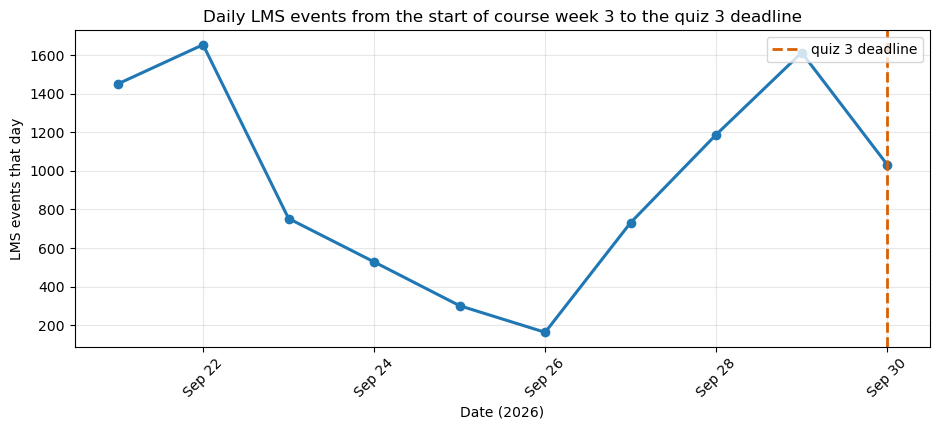

Course week 3 ran Sep 21 to Sep 27.
Quiz 3 was due Sep 29 at 23:59.
Days of click data plotted: 10   Last day in the whole export: Nov 01


In [16]:
# ✏️ EDIT THIS NUMBER (1 to 8). It runs as written.
FOCUS_WEEK = 3

# --- nothing below needs editing ---
FOCUS_WEEK = int(np.clip(FOCUS_WEEK, 1, 8))
this_deadline = deadlines[FOCUS_WEEK - 1]

# Window: the first day of that course week through the day after its quiz deadline.
start = clicks.loc[clicks['week'] == FOCUS_WEEK, 'timestamp'].min().normalize()
end   = this_deadline.normalize() + pd.Timedelta(days=1)
window = daily[(daily['date'] >= start) & (daily['date'] <= end)]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(window['date'], window['events'], color='#1f77b4', linewidth=2.2, marker='o')
ax.axvline(this_deadline, color='#d95f02', linestyle='--', linewidth=2,
           label='quiz %d deadline' % FOCUS_WEEK)
ax.set_xlim(start - pd.Timedelta(hours=12), end + pd.Timedelta(hours=12))
ax.set_title('Daily LMS events from the start of course week %d to the quiz %d deadline'
             % (FOCUS_WEEK, FOCUS_WEEK))
ax.set_xlabel('Date (2026)')
ax.set_ylabel('LMS events that day')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print('Course week %d ran %s to %s.' % (FOCUS_WEEK, start.strftime('%b %d'),
                                        (start + pd.Timedelta(days=6)).strftime('%b %d')))
print('Quiz %d was due %s.' % (FOCUS_WEEK, this_deadline.strftime('%b %d at %H:%M')))
print('Days of click data plotted: %d   Last day in the whole export: %s'
      % (len(window), clicks['timestamp'].max().strftime('%b %d')))

Two things to notice.

First, the window runs from the Monday that opens the course week to the Tuesday its quiz is due, because quiz *k* is due after week *k* has closed. A spike early in a course week is the tail of the **previous** quiz, not the run up to this one. Grain and timing conventions like that are where quietly wrong findings come from.

Second, try `FOCUS_WEEK = 8`. The click data stop on November 1 and quiz 8 is not due until November 3, so the line runs out before the deadline line does. Every real LMS export has an edge like that, and any per week comparison that includes week 8 without saying so is comparing a partial week against seven complete ones.

## 💬 8. Reflection: two traditions, one scatterplot

Take ten minutes with a partner. These questions are the reason the notebook exists.

**1. Baker and Inventado (2014), educational data mining and learning analytics.**
Today you did something both traditions do: reduce behavior to features, then look for structure. Sketch the next step twice.
- The educational data mining version: what would you automate, model, or predict from `panel`?
- The learning analytics version: whose decision would you inform, what would you show them, and how would a human's judgment stay in the loop?
Which of the two is your course project closer to right now, and is that on purpose?

**2. Nathan and Sawyer (2014), foundations of the learning sciences.**
Nathan and Sawyer describe learning as deep conceptual understanding built through activity in context, not as accumulated exposure. Look back at the scatterplot in Section 5.
- Which rung of the claim ladder can `total_events` actually reach, on their account of learning?
- Name one thing a learning sciences researcher would want to observe about EDUC 1010 that leaves no trace in any file we opened today.
- If you could add exactly one new column to this dataset to get closer to their idea of learning, what would it be, and how would you collect it without surveilling anybody?

**3. The eight students in the corner.**
You found them with two lines of code and a quantile. Would any dashboard you have ever seen have shown them to you? Should a dashboard show them at all, and to whom?

**4. One question this data cannot answer.**
Write it down. Bring it to the discussion. The best course projects in this seminar have started as exactly this kind of sentence.

## ✅ 9. Wrap up

**Nothing is due on Canvas for Week 2.** This notebook is in-class work. Mini Project 1 arrives in Week 4, and that is when the formal submission routine starts.

Before you close the tab:

- [ ] The notebook ran top to bottom with no red error boxes.
- [ ] You edited at least one ✏️ **Your turn** cell and saw a number move.
- [ ] You wrote something in the claim ladder text cell in Section 3.
- [ ] You have one sentence ready for discussion: a question this data cannot answer.
- [ ] Save your copy: **File > Save a copy in Drive**. Colab sessions do not persist, and the `data/` folder disappears when the runtime shuts down (the setup cell rebuilds it identically next time).

**On AI use.** No AI documentation is required this week, because nothing is submitted. Starting with Mini Project 1 in Week 4, every mini project upload to Canvas includes your completed notebook **plus** an AI interaction log **plus** a short reflection on how you used AI, per the course AI policy. Undisclosed AI use is an Honor Code matter. If you used a chatbot to make sense of `groupby` today, that is a fine use, and it is worth starting the habit now: keep a note of what you asked and what you did with the answer.

**Coming in Week 3.** We take the activity features you built today and train an actual at-risk model on them, then audit who it flags and who it misses. The eight students in the corner will be waiting.

## Appendix: solutions to the ✏️ Your turn cells

Try each one yourself first. These are here so nobody gets stuck, and so you can check your reading of the output.

### Your turn 1: a different feature

Any list of event types runs. Three worth trying:

```python
EVENT_TYPES = ['video_play']                       # r drops to about 0.28
EVENT_TYPES = ['forum_view']                       # r drops further, and some students hit zero
EVENT_TYPES = ['page_view', 'video_play', 'forum_view']   # r near the baseline of 0.335
```

What to notice: no single event type carries a stronger signal than the pile of everything, and narrower features push more students to zero. A student with zero of your chosen event type is invisible to your indicator, not absent from the course. That is a design decision with a person on the other end of it.

### Your turn 2: move the corner

```python
ACTIVITY_CUTOFF = 0.33 ; SCORE_CUTOFF = 0.75   # 8 students (the version in Section 5b)
ACTIVITY_CUTOFF = 0.25 ; SCORE_CUTOFF = 0.75   # a smaller group, still not empty
ACTIVITY_CUTOFF = 0.50 ; SCORE_CUTOFF = 0.60   # a much larger group, and a much weaker claim
```

What to notice: the group shrinks as you tighten the cutoffs but it does not disappear, and the students who survive every version are the ones worth talking about. Reporting a count without reporting the cutoffs that produced it is not a finding, it is a choice presented as a fact.

### Your turn 3: zoom in on one week

```python
FOCUS_WEEK = 1   # the opening rush of a new course
FOCUS_WEEK = 3   # a settled, typical week
FOCUS_WEEK = 8   # the export ends mid pattern
```

What to notice: week 8 runs to the end of the clickstream export on November 1, while quiz 8 is not due until November 3. The data simply stop before the story does. Every real LMS export has an edge like this, and any per week average that includes week 8 without saying so is comparing a partial week against seven complete ones.